# Tutorial: `custom` control in PyMuJoCo

This notebook shows how to run a Robotblockset robot with a user-defined MuJoCo control law instead of the default joint-position actuator behavior.

The workflow is:
- load a Panda scene,
- switch the actuators to direct torque input,
- define a robot subclass that stores command targets and registers a MuJoCo control callback,
- reuse the usual Robotblockset motion commands such as `JMove` and `CMoveFor`,
- inspect how the same custom controller behaves when the robot is stiff or compliant.

Use this pattern when the high-level motion generation in Robotblockset is still useful, but the low-level control law must be your own.

## Imports

The first cells load MuJoCo, Robotblockset utilities, plotting helpers, and notebook display tools. Nothing special is required for `custom` control yet; the important setup happens once the scene and actuators are created.

In [52]:
import time
import numpy as np
from copy import copy
import mediapy as media
import matplotlib.pyplot as plt

from IPython.display import clear_output
clear_output()

import mujoco
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, robot_pymujoco, panda
from robotblockset.transformations import rot_x, map_pose
from robotblockset.tools import get_rbs_path, print_xml
from robotblockset.mujoco.tools_pymujoco import print_body_tree_model, make_free_camera, get_robot_joints_data, get_joints_under_body, get_body_id, BODY

from robotblockset.robot_spec import panda_spec
from robotblockset.robots import MotionResultCodes
from robotblockset.tools import isvector, vector

np.set_printoptions(precision=3, suppress=True, linewidth=100)

## Motion Capture
We first define callback that stores the actual and commanded states during updates.

The callback is attached to the robot.


In [3]:
# Callback for Update
it = 0
def CaptureRobot(r):
    global it, tt, twall, trob, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    if it == 0:
        tt = np.array(r.t)
        twall = time.time()
        trob = r._robottime
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    else:
        tt = np.vstack((tt, r.t))
        twall = np.vstack((twall, time.time()))
        trob = np.vstack((trob, r._robottime))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

## 1. Initialize the simulation

This section builds the MuJoCo scene and prepares it for a custom low-level controller.

### Create the scene

The scene file already contains the Panda robot, the manipulated box, and the equality constraint used later to simulate grasping the load.

Printing the body tree is useful here because custom control depends on the MJCF model being wired correctly: joints, actuators, and any extra bodies or constraints must match the controller assumptions.

In [4]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
scene = mujoco_scene(f"{MODEL_PATH}panda_box_scene.xml", show_camera=None, verbose=1)
print_body_tree_model(scene.model, "world")

Body Tree for "world"
-world
--Target
--Box (Joints: Box-FREE)
--Load (Joints: Load-FREE)
--panda
---panda_link0
----panda_link1 (Joints: panda_joint1-HINGE)
-----panda_link2 (Joints: panda_joint2-HINGE)
------panda_link3 (Joints: panda_joint3-HINGE)
-------panda_link4 (Joints: panda_joint4-HINGE)
--------panda_link5 (Joints: panda_joint5-HINGE)
---------panda_link6 (Joints: panda_joint6-HINGE)
----------panda_link7 (Joints: panda_joint7-HINGE)
-----------panda_flange
------------panda_hand
-------------panda_left_finger (Joints: panda_finger_joint1-SLIDE)
-------------panda_right_finger (Joints: panda_finger_joint2-SLIDE)
-------------Panda_tool


Modify actuators to accept joint torques as inpput

In [5]:
for i in range(7):
    # actuator = scene.spec.actuator(scene.model.actuator(i).name)
    # actuator.name = actuator.name.replace("pos_", "mot_")
    actuator = scene.model.actuator(i)
    actuator.ctrlrange=[-1000, 1000] 
    actuator.biastype=mujoco.mjtBias.mjBIAS_NONE
    actuator.gainprm=[1] + [0]*9
    print(actuator.name)
    

panda_actuator1
panda_actuator2
panda_actuator3
panda_actuator4
panda_actuator5
panda_actuator6
panda_actuator7


In [6]:
robot_spec = mujoco.MjSpec.from_file(f"{MODEL_PATH}/panda.xml")

In [7]:
for i in range(7):
    actuator = robot_spec.actuator(f"actuator{i+1}")
    actuator.ctrlrange=[-1000, 1000] 
    actuator.biastype=mujoco.mjtBias.mjBIAS_NONE
    actuator.gainprm=[1] + [0]*9

In [8]:
# print_xml(robot_spec.to_xml())

### Define a robot subclass with `custom` control

This is the core of the tutorial.

The subclass keeps Robotblockset's robot model and motion API, but replaces the low-level actuation path with a MuJoCo callback:
- `control_target_q`, `control_target_qdot`, and `control_target_trq` store the current command target,
- `control_Kp`, `control_Kd`, `control_Kg`, and `control_use_H` parameterize the impedance law,
- `mujoco.set_mjcb_control(self.joint_impedance_control)` registers the controller that MuJoCo executes every simulation step.

`GoTo_q(...)` is the bridge from Robotblockset motion commands to the custom controller. High-level calls such as `JMove` or `CMoveFor` still generate joint references, and `GoTo_q(...)` simply updates the targets consumed by `joint_impedance_control(...)`.

Inside `joint_impedance_control(...)`, the controller reads the actual joint state, computes position and velocity error, adds optional gravity/bias compensation, and writes the resulting torques into `data.ctrl`. That is the essential `custom` pattern in PyMuJoCo.

In [9]:
class panda_joint_control(robot_pymujoco, panda_spec):
    def __init__(self, robot_name="panda", scene=None, ActuatorNames="auto", **kwargs):
        panda_spec.__init__(self)
        robot_pymujoco.__init__(self, robot_name, scene=scene, ActuatorNames=ActuatorNames, **kwargs)
        self.__dict__.update(kwargs)
        self.control_target_q = self.q_home.copy()
        self.control_target_qdot = np.zeros(self.nj)
        self.control_target_trq = np.zeros(self.nj)
        self.control_Kp = np.ones(self.nj) * 2500
        self.control_Kd = np.ones(self.nj) * 100
        self.control_Kg = 1
        self.control_use_H = True  # use inertia matrix in control
        self.control_e = np.zeros(self.nj)
        self.tsamp = scene.model.opt.timestep

        # set internal joint controller
        mujoco.set_mjcb_control(self.joint_impedance_control)

    def GoTo_q(self, q: np.ndarray, qdot: np.ndarray = None, trq: np.ndarray = None, wait: float = None, **kwargs) -> int:
        """Update target joint positions and velocities for internal controller and wait

        This method sets the joint positions (`q`), velocities (`qdot`), and torques (`trq`)
        for the internal controller.

        Parameters
        ----------
        q : np.ndarray, optional
            Desired joint positions (nj,).
        qdot : np.ndarray, optional
            Desired joint velocities (nj,).
        trq : np.ndarray, optional
            Desired joint torques (nj,).
        wait : float
            Time to wait (in seconds) after commanding the robot to move.

        Returns
        -------
        int
            Status of the move (0 for success, non-zero for error).
        """
        if qdot is None:
            qdot = np.zeros(self.nj)
        else:
            qdot = vector(qdot, dim=self.nj)
        if trq is None:
            trq = np.zeros(self.nj)
        else:
            trq = vector(trq, dim=self.nj)
        if wait is None:
            wait = self.tsamp

        self._synchro_control(wait)

        # set new target for internal controller
        self.control_target_q = q.copy()
        self.control_target_qdot = qdot.copy()
        self.control_target_trq = trq.copy()

        self._command.q = q.copy()
        self._command.qdot = qdot.copy()
        self._command.trq = trq.copy()
        if np.floor(self._command.mode) >= 1:
            x, J = self.Kinmodel(q)
            self._command.x = x
            self._command.v = J @ qdot
        self.Update()
        return MotionResultCodes.MOTION_SUCCESS.value

    def joint_impedance_control(self, model: mujoco.MjModel, data: mujoco.MjData) -> None:
        """
        Perform joint impedance control by computing the desired torques using PD (Proportional-Derivative)
        control law and applying them to the actuators.

        Parameters:
        -----------
        model : mujoco.MjModel
            The MuJoCo model object which contains the robot's physical parameters and properties.

        data : mujoco.MjData
            The MuJoCo data object that holds the current state of the robot, including joint positions, velocities,
            forces, and control commands.

        This function computes the torque required for each actuator based on the difference between
        the desired and actual joint positions and velocities. The computed torques are then applied
        to the actuators to drive the robot towards the desired state.

        The controller is a PD controller with an additional feed-forward term based on the
        joint force/torque bias (gravity, ...).

        Returns:
        --------
        None
        """
        # Get the current joint positions and velocities
        _q = np.take(self.scene.data.qpos.copy(), self._JointPosHandles)
        _qd = np.take(self.scene.data.qvel.copy(), self._JointVelHandles)

        # Compute the position and velocity errors
        self.control_e = self.control_target_q - _q
        self.control_ed = self.control_target_qdot - _qd

        # Compute the joint torques using the PD control law, plus feed-forward based on joint force bias
        if self.control_use_H:
            _tq = self.H @ (self.control_Kp * self.control_e + self.control_Kd * self.control_ed) + self.control_Kg * data.qfrc_bias[self._JointVelHandles]
        else:
            _tq = (self.control_Kp * self.control_e + self.control_Kd * self.control_ed) + self.control_Kg * data.qfrc_bias[self._JointVelHandles]

        # Apply the computed torques to the actuators
        _ctrl = data.ctrl.copy()  # Copy current control values
        for i, x in zip(self._ActuatorHandles, _tq):
            _ctrl[i] = x  # Set the control for each actuator to the computed torque
        data.ctrl = _ctrl  # Update the control command in the data object


### Instantiate and reset the robot

Now the custom subclass is used exactly like any other Robotblockset robot. `Restart(...)` resets the simulated state, and `ResetCurrentTarget()` aligns the internal command target with the current robot configuration before any motion starts.

In [10]:
r = panda_joint_control(scene=scene)
r.Restart(keyframe=0)
r.ResetCurrentTarget()

[RBS_INFO] [19:00:24] [panda_PyMuJoCo]: Robot connected to MuJoCo


0

### Prepare logging

The callback defined earlier stores commanded and measured joint/task states over time. This is optional for control, but it is very useful when tuning a `custom` controller because it lets you compare reference tracking against the actual robot response.

### Start from a stiff controller

These gains create a high-stiffness joint impedance controller. This is a good baseline because it makes the effect of external loading easy to see before switching to a compliant setting.

In [11]:
r.control_Kp = np.ones(r.nj)*2500
r.control_Kd = np.ones(r.nj)*1000

### Move to the home configuration

`JMove(r.q_home)` uses the standard Robotblockset joint motion pipeline. The difference is that the final low-level command is no longer a built-in MuJoCo position actuator target; instead, the trajectory updates the target variables consumed by the custom torque callback.

The printed task-space position error is the first quick check that the controller tracks well with no external load attached.

In [12]:
r.JMove(r.q_home)
q1 = r.q_ref.copy()
r.Wait(2)

In [77]:
print("Robot stiff, NO load  - Task position error:", r.p_err)

Robot stiff, NO load  - Task position error: [ 0.019 -0.003  0.08 ]


### Attach the load and measure the stiff response

The equality constraint `Grasp_load` rigidly connects the object to the gripper. With the same high gains, the robot should remain close to the commanded pose even after the payload is attached.

This block shows the reference behavior of the custom controller when stiffness dominates.

In [72]:
r.SetEquality("Grasp_load", True)
r.Wait(3)
print("Robot stiff, with load - Task position error:", r.p_err, 'Force at end-effector:', r.F)

Robot stiff, with load - Task position error: [0.002 0.003 0.002] Force at end-effector: [ 4.158 -1.492  0.962]


### Reduce gains to make the robot compliant

Here only the controller parameters change; the same `custom` control structure stays in place. Lower `Kp` and `Kd` make the robot softer, so the effect of gravity and payload becomes visible in both pose error and end-effector wrench.

The next cells compare three situations:
- compliant with load attached,
- compliant after releasing the load,
- stiff again after restoring the original gains.

In [88]:
r.control_Kp = np.ones(r.nj)*25
r.control_Kd = np.ones(r.nj)*10

In [27]:
r.SetEquality("Grasp_load", True)
r.Wait(3)
print("Robot compliant, with load - Task position error:", r.p_err, 'Force at end-effector:', r.F)

Robot compliant, with load - Task position error: [ 0.021 -0.003  0.08 ] Force at end-effector: [ -2.694  -0.315 -17.855]


In [28]:
r.SetEquality("Grasp_load", False)
r.Wait(3)
print("Robot compliant, NO load - Task position error:", r.p_err, 'Force at end-effector:', r.F)

Robot compliant, NO load - Task position error: [ 0.    -0.    -0.003] Force at end-effector: [ 0.082 -0.001 -7.377]


In [31]:
r.control_Kp = np.ones(r.nj)*2500
r.control_Kd = np.ones(r.nj)*1000

## 2. Run a motion under `custom` control

This sequence records a short Cartesian motion and the return to home.

`CMoveFor([0.2, -0.3, 0.1])` is intentionally kept unchanged to emphasize the key idea: the high-level API does not need to change when you switch to a custom controller. Robotblockset still plans the motion, while the MuJoCo callback is responsible for turning the generated joint targets into actuator torques.

In [20]:
r.SetCaptureCallback(CaptureRobot)
# r.Restart()
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.2, -0.3, 0.1])
r.Wait(1)
r.JMove(r.q_home)
r.Wait(1)
r.StopCapture()


## 3. Visualize the setup

The next cells render the scene from a fixed free camera so you can confirm the geometry, grasped object, and executed motion before looking at plots.

""

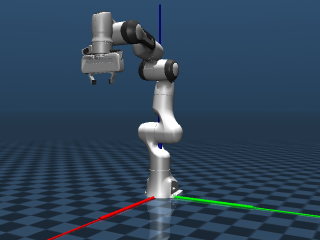

In [9]:
cam = make_free_camera(r.scene.model, azimuth=210, elevation=-2, distance=2.0, lookat=[0,0,0.4], fovy=35)
frame = scene.mj_capture_camera(camera=cam)
media.show_image(frame)

## 4. Inspect tracking data

The logged trajectories make it easier to tune the custom controller:
- joint position plots show how tightly the robot follows the generated references,
- joint velocity plots help identify overshoot, damping issues, or overly aggressive gains.

For practical controller development, this type of plot is usually the fastest way to judge whether a `custom` control law is stable, accurate, and appropriately compliant.

Text(0, 0.5, '$\\dot q$')

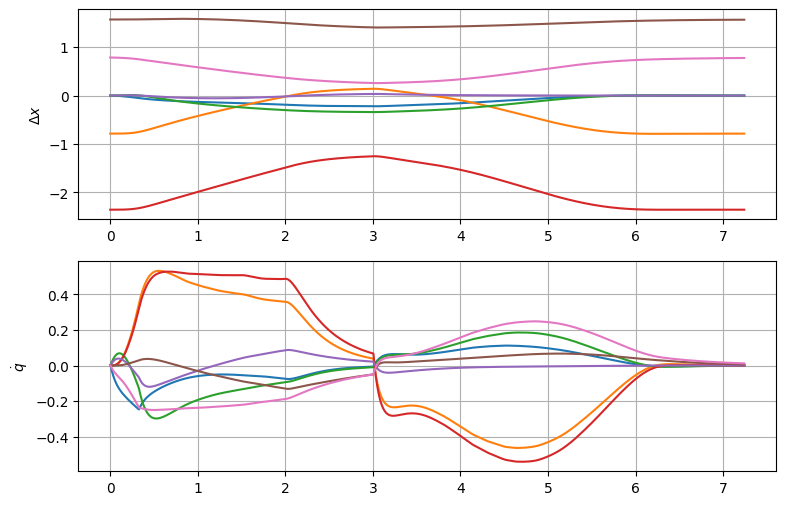

In [18]:
fig, ax = plt.subplots(2, 1, num=1, figsize=(9, 6))
ax[0].plot(tt,qt, label="$q$")
ax[0].grid()
ax[0].set_ylabel("$\\Delta x$")
ax[1].plot(tt, qdt, label="$\\dot q$")
ax[1].grid()
ax[1].set_ylabel("$\\dot q$")